https://github.com/4GeeksAcademy/decision-tree-project-tutorial/blob/main/solution.es.ipynb

In [180]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from missforest import MissForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import shap
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.tree import DecisionTreeClassifier, export_text #https://scikit-learn.org/stable/modules/tree.html
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.metrics import specificity_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [152]:
# FUNCIONES
## Formato 5 decimales
pd.options.display.float_format = '{:,.5f}'.format 

## Metricas de clasificacion
def metricas_clas(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy,train_recall,train_specificity,train_precision,train_f1],
                               [test_accuracy, test_recall, test_specificity, test_precision,test_f1],
                               [diff_accuracy, diff_recall, diff_specificity, diff_precision, diff_f1]],
                              columns = ['Accuracy', 'Recall', 'Specificity', 'Precision', 'F1'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

# **0. CONTEXTO Y CARGA DATOS**

Fuente: https://github.com/4GeeksAcademy/random-forest-project-tutorial/blob/main/README.es.md

Descripción de variables: 

- Pregnancies. Número de embarazos del paciente (numérico)

- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)

- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)

- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)

- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)

- BMI. Índice de masa corporal (numérico)

- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)

- Age. Edad del paciente (numérico)

- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

Descripción del proyecto:

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.


In [29]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [30]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores

### 1.1.1. Unicos

In [31]:
#Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [32]:
#Indice
dup_fil=df.duplicated().sum()
print("No hay filas duplicadas" if dup_fil==0 else "Hay filas duplicadas")

No hay filas duplicadas


In [33]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

In [34]:
# Columnas columnas con más de un 15% de valores faltantes
missing=df.isna().mean()*100
missing[missing>15]

Series([], dtype: float64)

<Axes: >

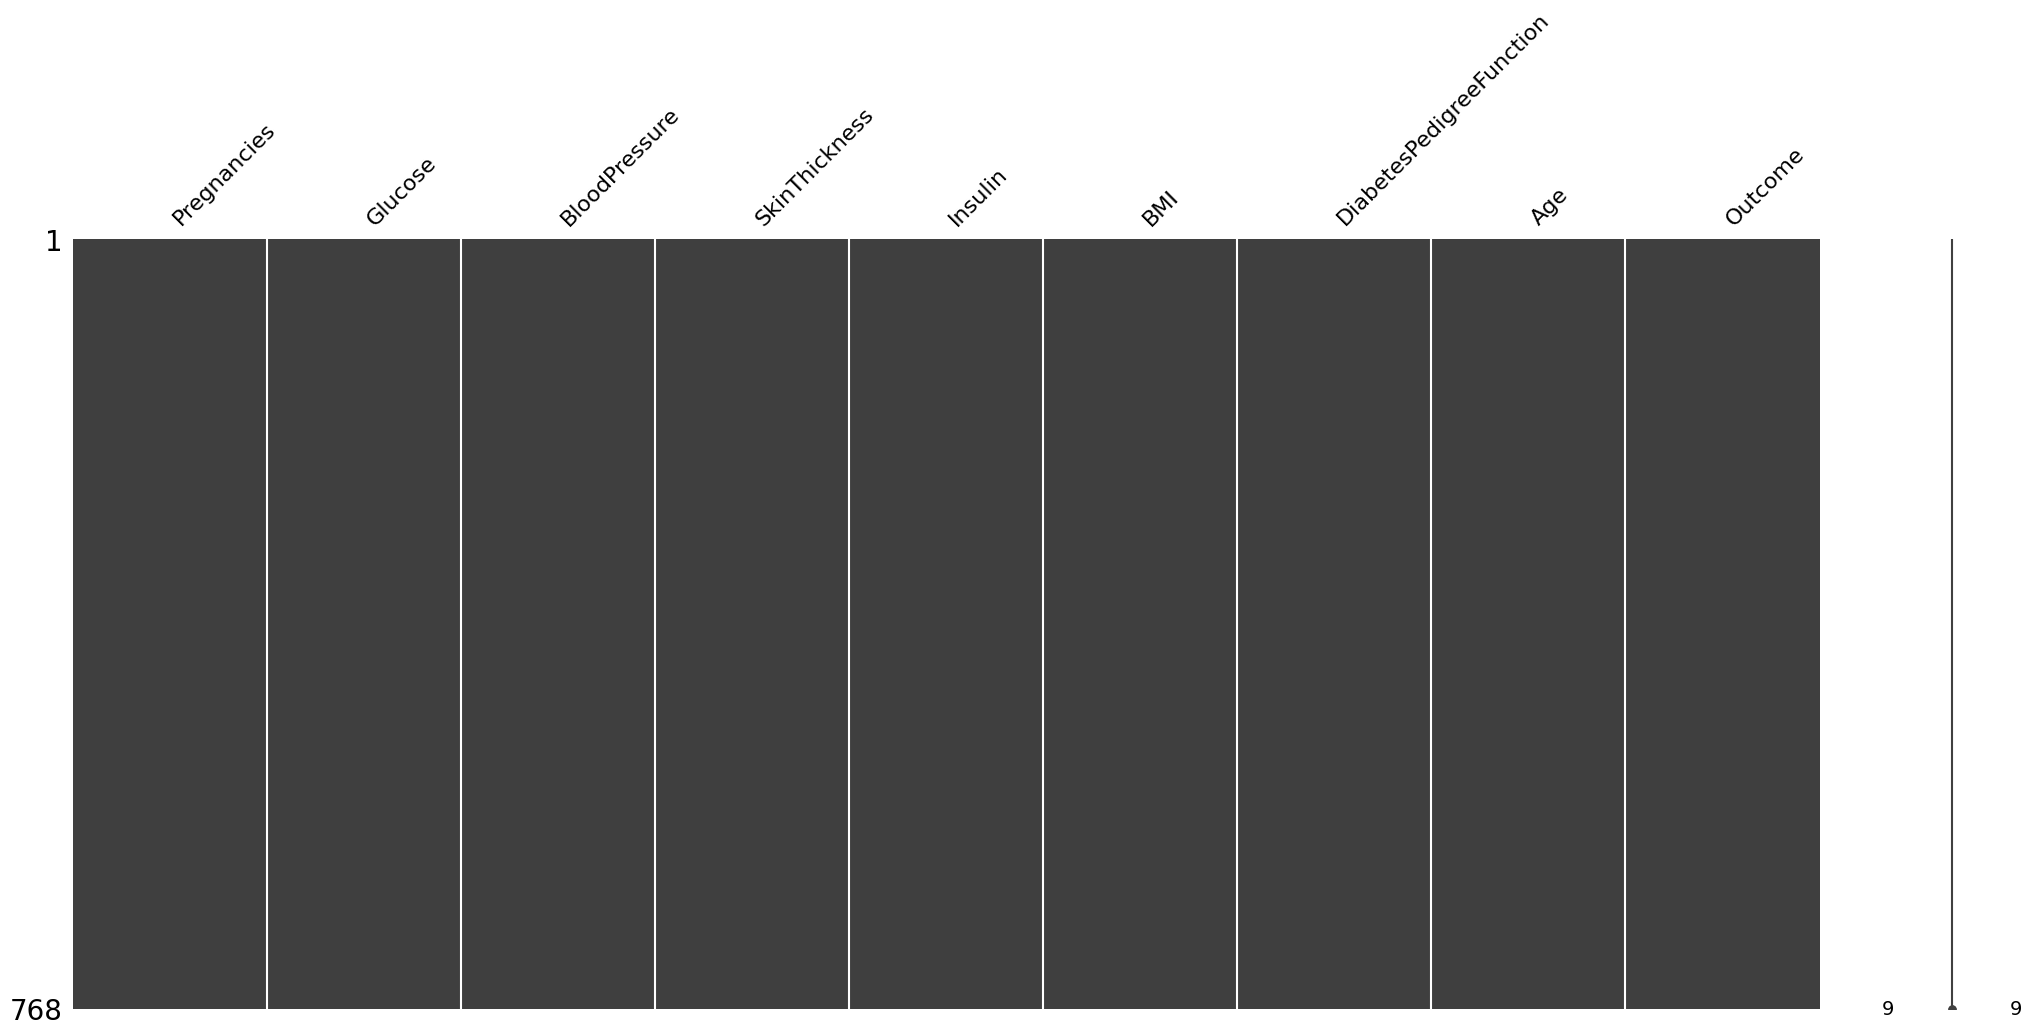

In [35]:
# Gráficamente
msno.matrix(df)

## 1.3. Análisis Univariante

### 1.3.1. Variables numéricas

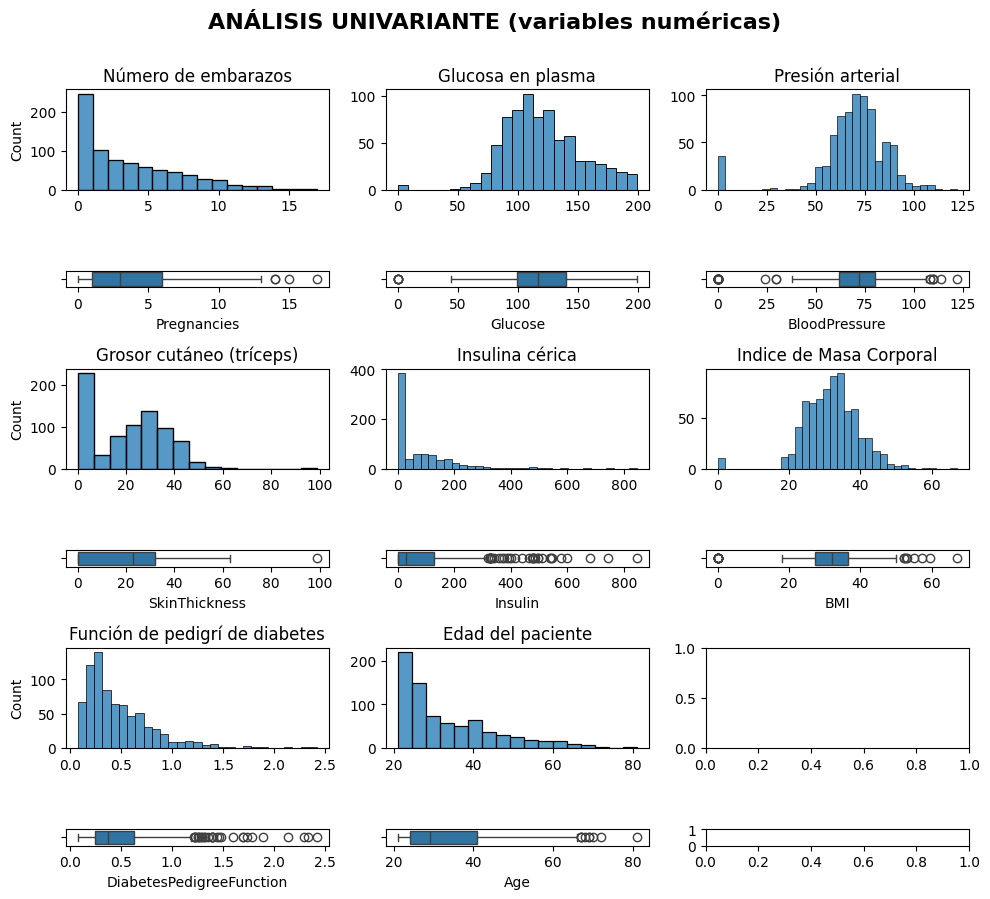

In [36]:
fig, axis = plt.subplots(6, 3, figsize = (10, 10), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1]}) #height_ratios: cambiar tamaño relativo de los graficos

#Primera Fila
sns.histplot(ax = axis[0, 0], data = df, x = "Pregnancies").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "Pregnancies")
axis[0, 0].set_title("Número de embarazos")
sns.histplot(ax = axis[0, 1], data = df, x = "Glucose").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "Glucose")
axis[0, 1].set_title("Glucosa en plasma")
sns.histplot(ax = axis[0, 2], data = df, x = "BloodPressure").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 2], data = df, x = "BloodPressure")
axis[0, 2].set_title("Presión arterial")

#Segunda Fila
sns.histplot(ax = axis[2, 0], data = df, x = "SkinThickness").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "SkinThickness")
axis[2, 0].set_title("Grosor cutáneo (tríceps)")
sns.histplot(ax = axis[2, 1], data = df, x = "Insulin").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "Insulin")
axis[2, 1].set_title("Insulina cérica")
sns.histplot(ax = axis[2, 2], data = df, x = "BMI").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 2], data = df, x = "BMI")
axis[2, 2].set_title("Indice de Masa Corporal")

#Tercera Fila
sns.histplot(ax = axis[4, 0], data = df, x = "DiabetesPedigreeFunction").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = df, x = "DiabetesPedigreeFunction")
axis[4, 0].set_title("Función de pedigrí de diabetes")
sns.histplot(ax = axis[4, 1], data = df, x = "Age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = df, x = "Age")
axis[4, 1].set_title("Edad del paciente")

# Ajustes visuales
plt.subplots_adjust(hspace=0.5, wspace=0.3) # hspace: Espacio vertical | wspace: Espacio horizontal
fig.suptitle("ANÁLISIS UNIVARIANTE (variables numéricas)", fontsize=16, fontweight="bold", y=0.955)
# rect=[0, 0.03, 1, 0.95] ajusta los márgenes para que el suptitle no corte los gráficos.
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

#### Tratamiento de valores extraños

Vamos a investigar los casos con valores 0:
- Glucosa: valores normales 16-166 mlU/L
    - Fuente: https://www.metropolisindia.com/blog/preventive-healthcare/what-is-an-insulin-test-its-uses-and-test-results#:~:text=are%20working%20efficiently.-,Understanding%20the%20Test%20Results%20of%20the%20Fasting%20Insulin%20Test,depend%20on%20factors%20such%20as
- Presion aterial sistolica: valores normales 80-120
    - Fuente: https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings#:~:text=Use%20our%20blood%20pressure%20chart%20to%20learn,and%20the%20difference%20between%20systolic%20and%20diastolic.
- Grosor de la piel: valores normales 5-32
    - Fuente https://pmc.ncbi.nlm.nih.gov/articles/PMC4579544/
- Insulina: valores normales 20-250
    - Fuente: https://www.apollohospitals.com/diagnostics-investigations/insulin-test#:~:text=Normal%20Range%20for%20the%20Insulin,and%20monitoring%20several%20health%20conditions:
- IMC: valores normales 18.5-24.9
    - Fuente: https://institutojesuslago.com/en/imc-calculator.php

Luego, con esta información, podemos deducir que los valores 0 son nulos

C:\Users\jjime\AppData\Local\Temp\ipykernel_12696\4026305487.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[var].replace({0: np.nan}, inplace=True)


<Axes: >

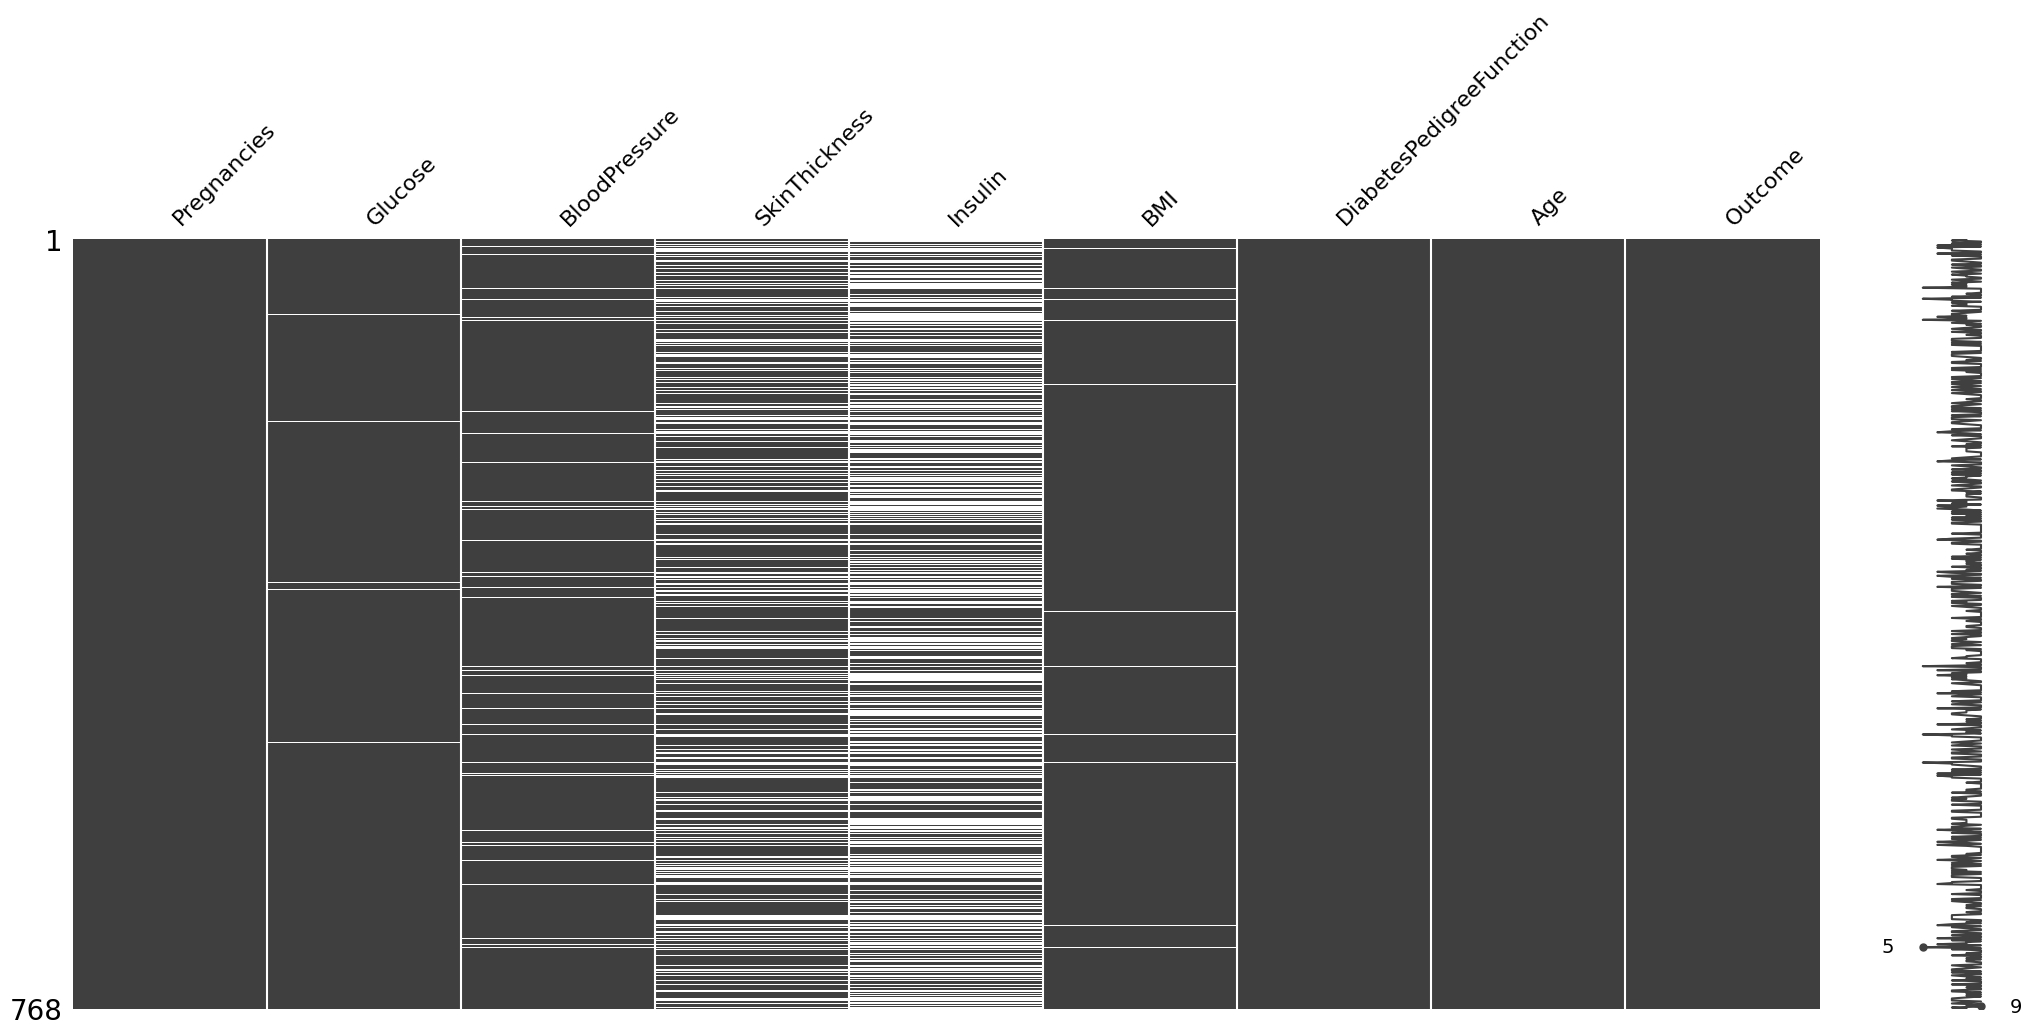

In [37]:
columnas=["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
#Iteramos por las columnas anteriores para imputar 0 como NaN
for var in columnas:
    df[var].replace({0: np.nan}, inplace=True)

# Mostramos msno ahora
msno.matrix(df)

In [38]:
# Análisis final de los valores por columnas
col_na=df.isna().sum()/len(df)
col_na[col_na>0.2]

SkinThickness    0.295573
Insulin          0.486979
dtype: float64

In [39]:
# Busqueda de patrones
df[df["Insulin"].isna()].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,374.000000,370.000000,339.000000,147.000000,0.0,364.000000,374.000000,374.000000,374.000000
mean,4.433155,120.700000,74.439528,29.278912,NaN,31.793407,0.415340,35.796791,0.368984
std,3.437621,30.238604,11.979706,10.438195,NaN,6.763519,0.300547,12.729034,0.483176
min,0.000000,44.000000,44.000000,8.000000,NaN,18.200000,0.078000,21.000000,0.000000
25%,1.000000,100.250000,66.000000,22.000000,NaN,26.800000,0.209000,25.000000,0.000000
50%,4.000000,115.000000,74.000000,30.000000,NaN,31.200000,0.302500,32.000000,0.000000
75%,7.000000,138.000000,82.000000,35.500000,NaN,35.725000,0.553250,43.000000,1.000000
max,14.000000,199.000000,122.000000,99.000000,NaN,52.900000,1.893000,72.000000,1.000000


In [40]:
# Eliminamos la columna al no observar ningun patron
df.drop(columns="Insulin", inplace=True)

In [41]:
#Verificamos si hay filas que tiene más de 3 columnas con NaN (37.5%)
filas=df.T.isna().sum()
print("No hay filas con más de 3 variables sin valores" if len(filas[filas>=3])==0 
      else f"Hay {len(filas[filas>=3])} observaciones con más de 3 variables sin valores")

Hay 7 observaciones con más de 3 variables sin valores


In [42]:
#Visualizamos las filas para analizar patrones
df.iloc[filas[filas>=3].index]

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
49,7,105.0,NaN,NaN,NaN,0.305,24,0
60,2,84.0,NaN,NaN,NaN,0.304,21,0
81,2,74.0,NaN,NaN,NaN,0.102,22,0
426,0,94.0,NaN,NaN,NaN,0.256,25,0
494,3,80.0,NaN,NaN,NaN,0.174,22,0
522,6,114.0,NaN,NaN,NaN,0.189,26,0
706,10,115.0,NaN,NaN,NaN,0.261,30,1


In [43]:
# Eliminamos observaciones al no haber ningun patron
elm_fil=filas[filas>=3].index
df.drop(elm_fil, axis=0, inplace=True)

In [44]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

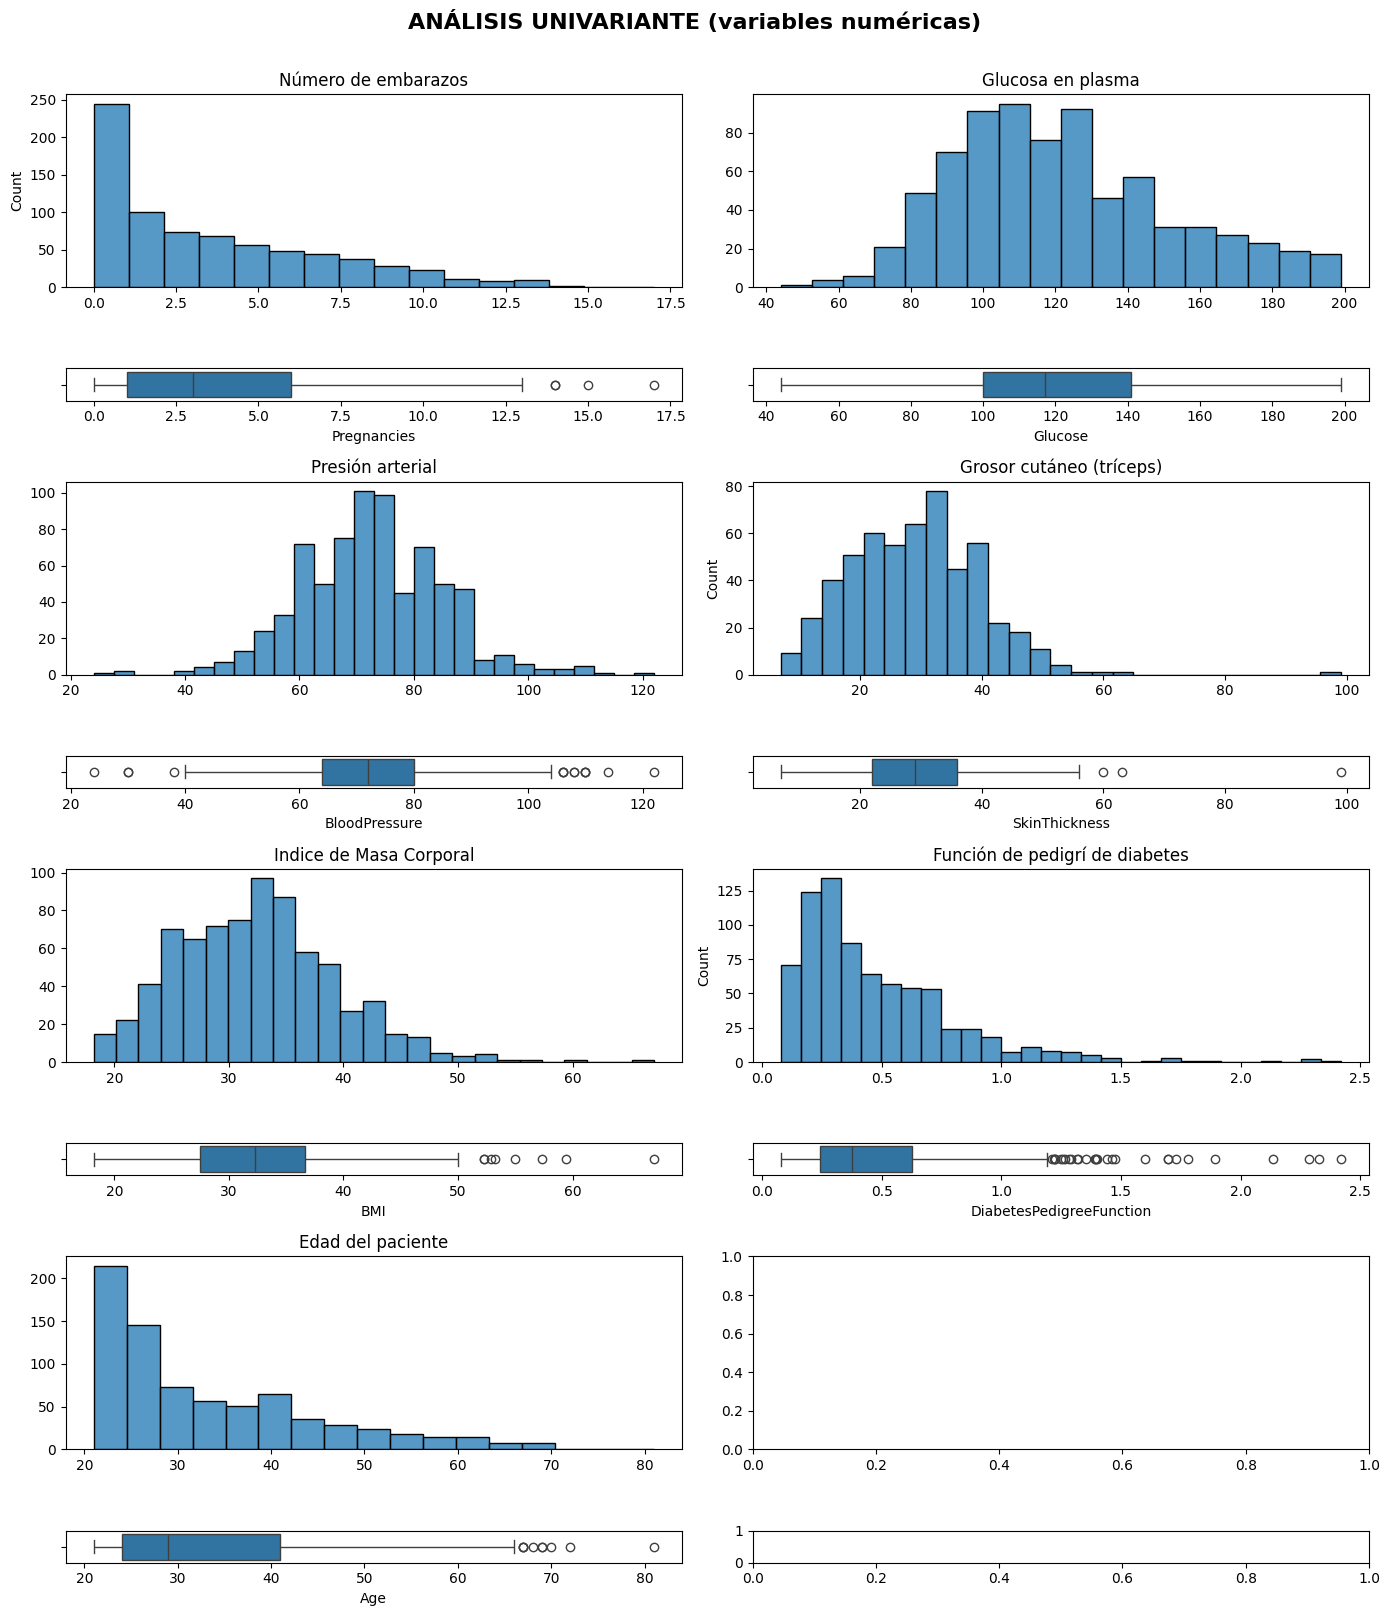

In [ ]:
# Visualizamos la base de datos resultante
fig, axis = plt.subplots(8, 2, figsize = (14, 18), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1, 6, 1]}) #height_ratios: cambiar tamaño relativo de los graficos

#Primera Fila
sns.histplot(ax = axis[0, 0], data = df, x = "Pregnancies").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "Pregnancies")
axis[0, 0].set_title("Número de embarazos")
sns.histplot(ax = axis[0, 1], data = df, x = "Glucose").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "Glucose")
axis[0, 1].set_title("Glucosa en plasma")

#Segunda Fila
sns.histplot(ax = axis[2, 0], data = df, x = "BloodPressure").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "BloodPressure")
axis[2, 0].set_title("Presión arterial")
sns.histplot(ax = axis[2, 1], data = df, x = "SkinThickness").set(xlabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "SkinThickness")
axis[2, 1].set_title("Grosor cutáneo (tríceps)")

#Tercera Fila
sns.histplot(ax = axis[4, 0], data = df, x = "BMI").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 0], data = df, x = "BMI")
axis[4, 0].set_title("Indice de Masa Corporal")
sns.histplot(ax = axis[4, 1], data = df, x = "DiabetesPedigreeFunction").set(xlabel = None)
sns.boxplot(ax = axis[5, 1], data = df, x = "DiabetesPedigreeFunction")
axis[4, 1].set_title("Función de pedigrí de diabetes")

#Cuarta Fila
sns.histplot(ax = axis[6, 0], data = df, x = "Age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 0], data = df, x = "Age")
axis[6, 0].set_title("Edad del paciente")
axis[6,1].remove()
axis[7,1].remove()

# Ajustes visuales
plt.subplots_adjust(hspace=0.6, wspace=0.3) # hspace: Espacio vertical | wspace: Espacio horizontal
fig.suptitle("ANÁLISIS UNIVARIANTE (variables numéricas)", fontsize=16, fontweight="bold", y=0.955)
# rect=[0, 0.03, 1, 0.95] ajusta los márgenes para que el suptitle no corte los gráficos.
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

In [46]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

### 1.3.2. Target

[]

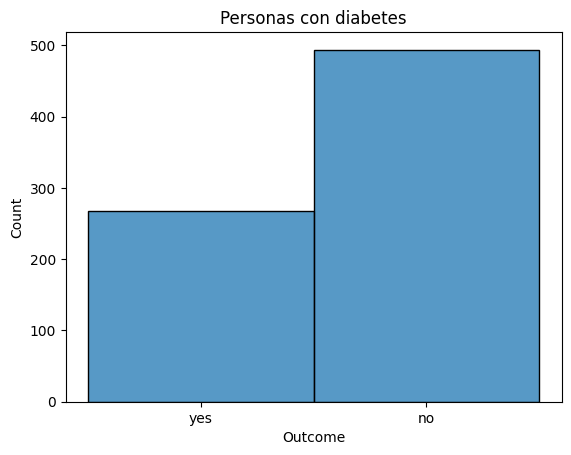

In [47]:
sns.histplot(df["Outcome"].replace({0: "no", 1:"yes"}))
plt.title("Personas con diabetes")
plt.plot()

## 1.4. Análisis (Numérico-Categorico)

### 1.4.1. Matriz de correlaciones 

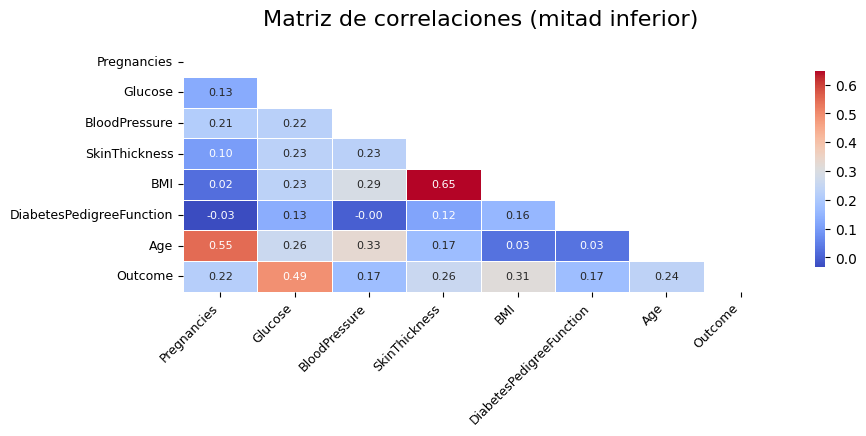

In [48]:
#Mapa de correlaciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    df.corr(), mask=np.triu(np.ones_like(df.corr(), dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

En este caso, podemos ver una fuerte relación entre:
- Age-Pregnancies &rarr; creamos embarazos por cada 5 años de edad fértil (21-51 años)

- SkinThickness-BMI &rarr; se evaluará en selección de características

In [49]:
# Limite máximo de fertilidad
df["Fertil_max"]=51
df.loc[df["Age"]<51, "Fertil_max"]=df.loc[df["Age"]<51, "Age"]

# Limite mínimo: edad mínima de la base de datos
df["Fertil_min"]=df["Age"].min()-1

# Años fértiles
df["Age2"]=df["Fertil_max"]-df["Fertil_min"]

# VARIABLE OBJETIVO: embarazos por cada 5 años potencialmente fértiles
df["Pregnancies2"]=df["Pregnancies"]/(df["Age2"]/5)

In [50]:
# Ajustes 
col_elm=["Pregnancies", "Fertil_max", "Fertil_min", "Age2"]
df.drop(columns=col_elm, inplace=True)
df.columns

Index(['Glucose', 'BloodPressure', 'SkinThickness', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Pregnancies2'],
      dtype='object')

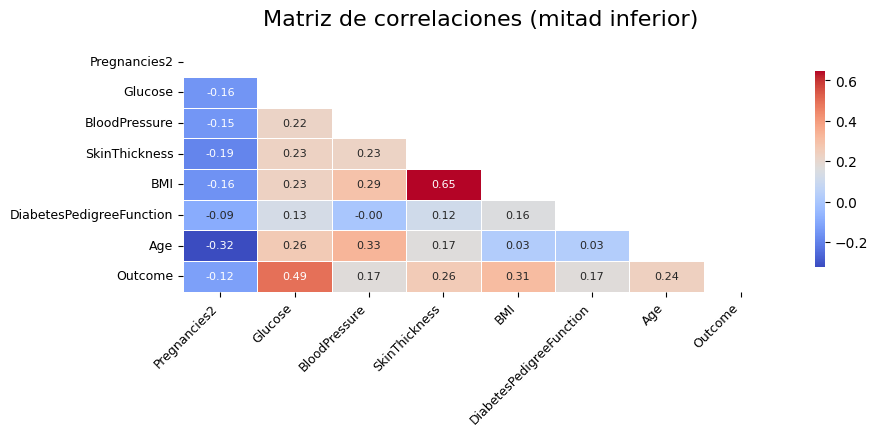

In [51]:
df=df[['Pregnancies2', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome']]
# Mostramos matriz con correcciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    df.corr(), mask=np.triu(np.ones_like(df.corr(), dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

### 1.4.2. Box plot por outcome

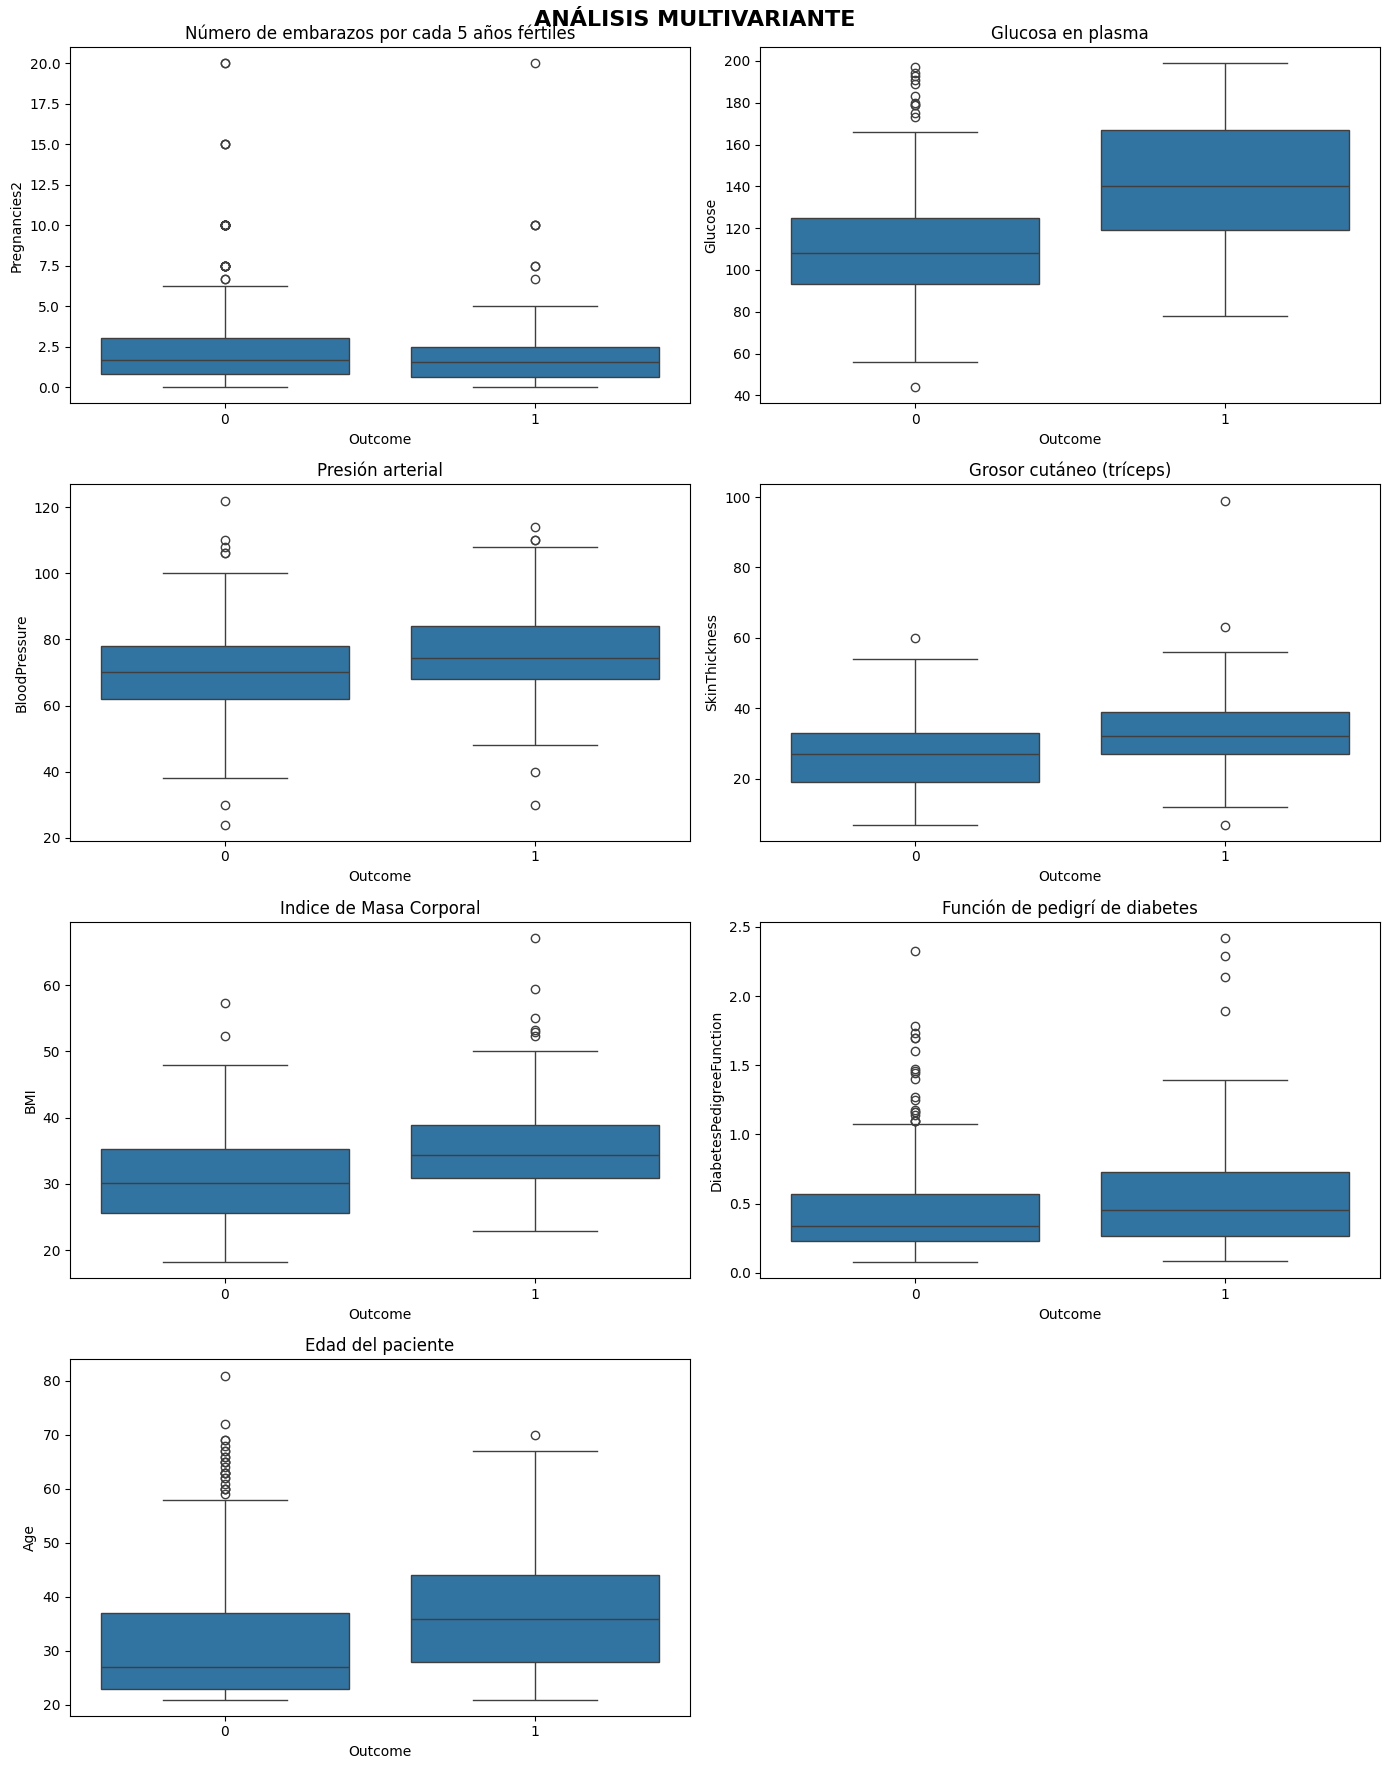

In [52]:
# Diabetes por cada variable
fig, axis = plt.subplots(4, 2, figsize = (14, 18))

#Primera Fila
sns.boxplot(ax = axis[0, 0], data = df, x="Outcome", y = "Pregnancies2")
axis[0, 0].set_title("Número de embarazos por cada 5 años fértiles")
sns.boxplot(ax = axis[0, 1], data = df, x="Outcome", y = "Glucose")
axis[0, 1].set_title("Glucosa en plasma")

#Segunda Fila
sns.boxplot(ax = axis[1, 0], data = df, x="Outcome", y = "BloodPressure")
axis[1, 0].set_title("Presión arterial")
sns.boxplot(ax = axis[1, 1], data = df, x="Outcome", y = "SkinThickness")
axis[1, 1].set_title("Grosor cutáneo (tríceps)")

#Tercera Fila
sns.boxplot(ax = axis[2, 0], data = df, x="Outcome", y ="BMI")
axis[2, 0].set_title("Indice de Masa Corporal")
sns.boxplot(ax = axis[2, 1], data = df, x="Outcome", y ="DiabetesPedigreeFunction")
axis[2, 1].set_title("Función de pedigrí de diabetes")

#Cuarta Fila
sns.boxplot(ax = axis[3, 0], data = df, x="Outcome", y ="Age")
axis[3, 0].set_title("Edad del paciente")
axis[3, 1].remove()

# Ajustes visuales
fig.suptitle("ANÁLISIS MULTIVARIANTE", fontsize=16, fontweight="bold")
# rect=[0, 0.03, 1, 0.95] ajusta los márgenes para que el suptitle no corte los gráficos.
plt.tight_layout()
plt.show()

### 

### 1.4.3. Gráfico resumen

[]

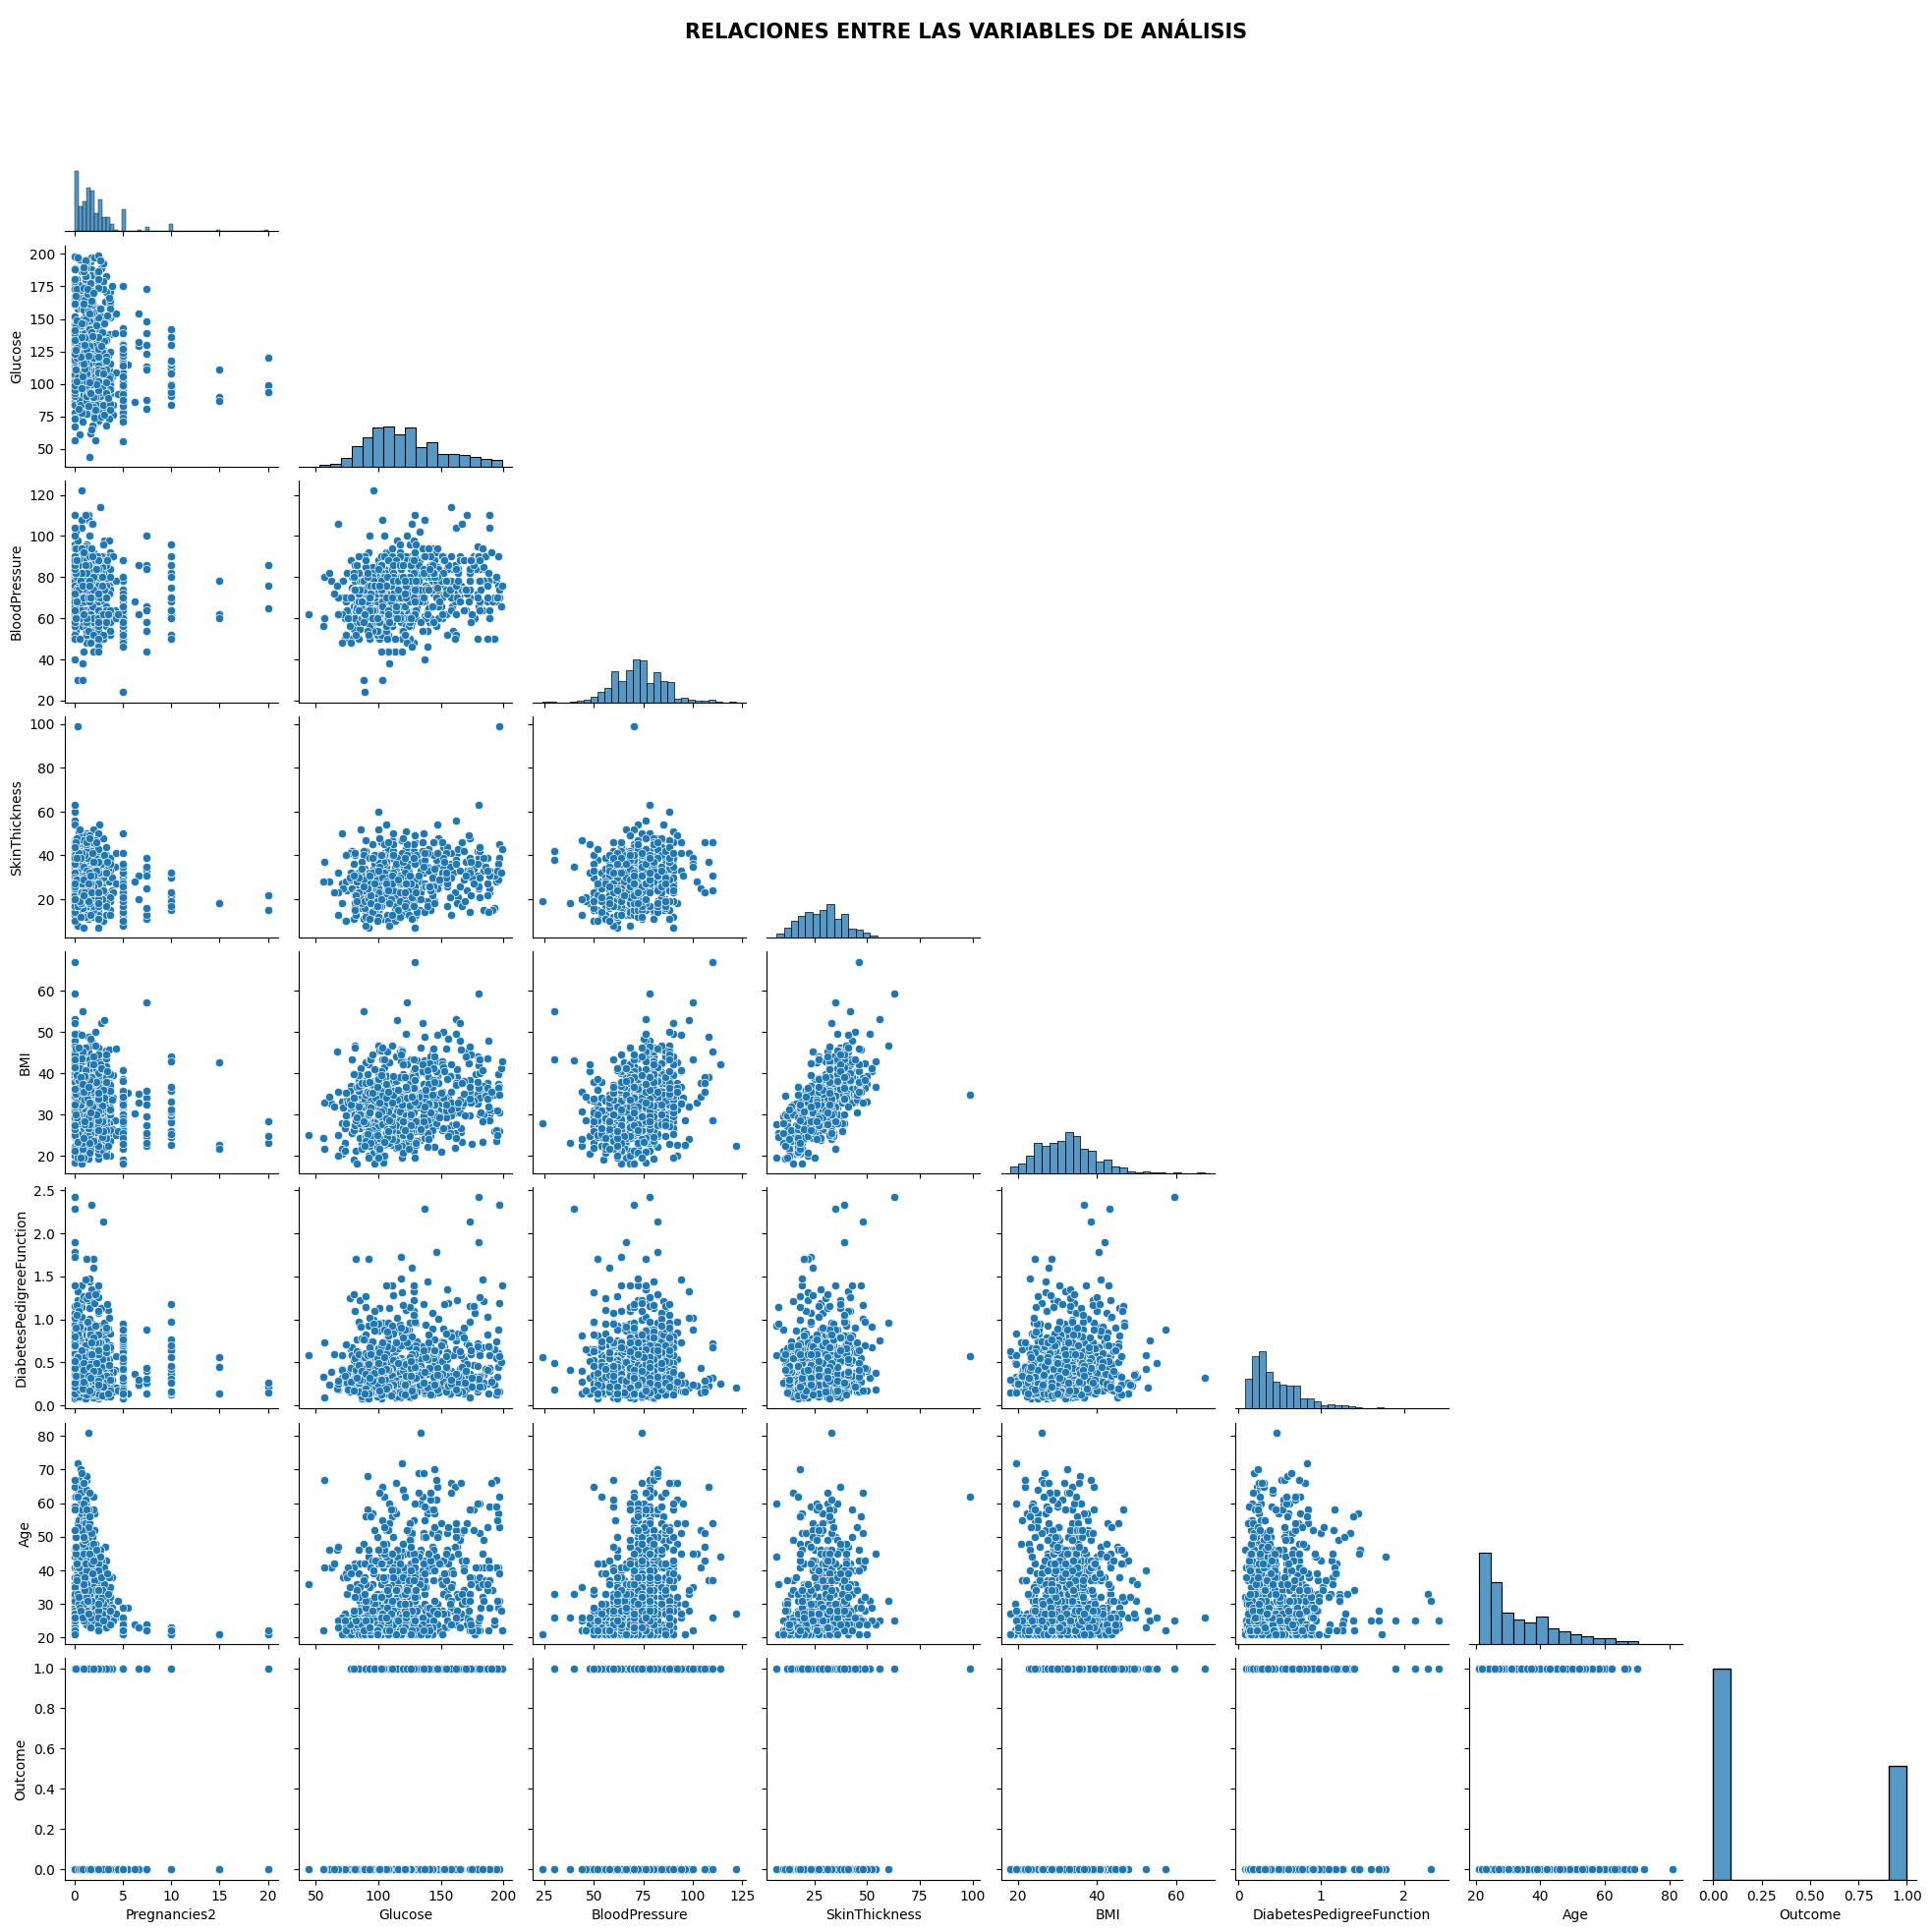

In [53]:
sns.pairplot(data=df, corner=True)
plt.suptitle("Relaciones entre las variables de análisis".upper(), fontweight="bold", size=15)
plt.plot()

## 1.5. División Train-Test

In [54]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)
X_train.head()

,Pregnancies2,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
364,2.000000,147.0,74.0,25.0,34.9,0.385,30
269,1.250000,146.0,NaN,NaN,27.5,0.240,28
93,0.645161,134.0,72.0,NaN,23.8,0.277,60
372,0.000000,84.0,64.0,22.0,35.8,0.545,21
582,1.935484,121.0,78.0,17.0,26.5,0.259,62


## 1.5.1. Imputación de Missing Values

In [55]:
X_train.describe()

,Pregnancies2,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
count,608.000000,604.000000,589.000000,443.000000,604.000000,608.000000,608.000000
mean,2.175633,121.847682,71.960951,29.259594,32.509437,0.480678,33.485197
std,2.363409,30.157629,12.133757,10.522025,6.725967,0.338161,11.945915
min,0.000000,56.000000,24.000000,7.000000,18.200000,0.084000,21.000000
25%,0.806452,100.000000,64.000000,22.000000,27.600000,0.245750,24.000000
50%,1.666667,118.000000,72.000000,29.000000,32.400000,0.389000,29.000000
75%,2.500000,140.000000,80.000000,36.000000,36.600000,0.637000,41.000000
max,20.000000,199.000000,122.000000,99.000000,59.400000,2.420000,81.000000


In [56]:
#Instanciamos MissForest
imputer = MissForest()

#Base de datos train
## - .fit_transform() entrena el modelo y predice los valores faltantes
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

#Base de datos test
## - .transform() aplica el modelo anterior en unos nuevos datos
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
  0%|          | 0/5 [00:00<?, ?it/s]

 40%|████      | 2/5 [00:10<00:13,  4.63s/it]c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:303: UserWarning: NRMSE increased.
  warnings.warn("NRMSE increased.")
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:453: UserWarning: Stopping criterion triggered during fitting. Before last imputation matrix will be returned.
  warnings.warn(
 40%|████      | 2/5 [00:12<00:18,  6.28s/it]
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now

In [57]:
# Comprobamos eliminacion de missing values
X_train_imp.isna().sum()[X_train_imp.isna().sum()>0]/len(X_train_imp)*100

Series([], dtype: float64)

## 1.6. Análisis de valores Outliers

In [58]:
#Primer análisis de outliers (diferncia media-mediana)
variables=X_train_imp.columns
result=[]
for var in variables:
    result.append(np.abs(X_train_imp[var].mean()-X_train_imp[var].median())/X_train_imp[var].median()*100)

outliers=pd.Series(result, index=variables)
outliers[outliers>20]

Pregnancies2                30.537964
DiabetesPedigreeFunction    23.567515
dtype: float64

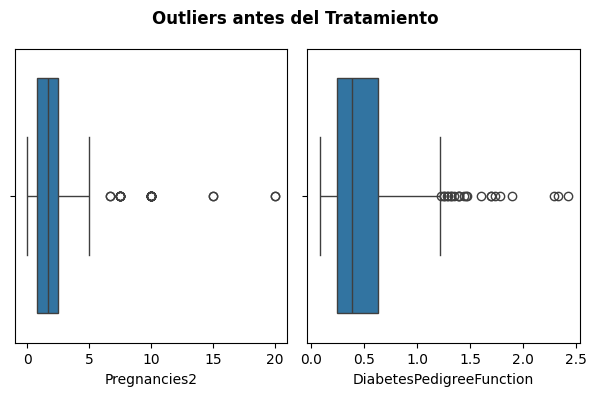

In [59]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, axis = plt.subplots(1, 2, figsize=(6, 4))

# Crear un histograma en el primer subplot
# Primera fila
sns.boxplot(data=X_train_imp, x="Pregnancies2", ax=axis[0])
sns.boxplot(data=X_train_imp, x="DiabetesPedigreeFunction", ax=axis[1])
fig.suptitle("Outliers antes del Tratamiento", fontweight="bold")


# Mostrar la figura
plt.tight_layout()
plt.show()

In [60]:
X_train_imp[X_train_imp["Pregnancies2"]>5]["Age"].describe()

count    30.000000
mean     21.633333
std       0.668675
min      21.000000
25%      21.000000
50%      22.000000
75%      22.000000
max      23.000000
Name: Age, dtype: float64

En este caso, se aprecia como Pregnancies2 y DiabetesPedigreeFunction tienen un número elevado de outliers. 

- Pregnancies2 lo dejaremos igual porque los outliers se concentran en personas jóvenes.
- A DiabetesPedigreeFunction aplicaremos logaritmos

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


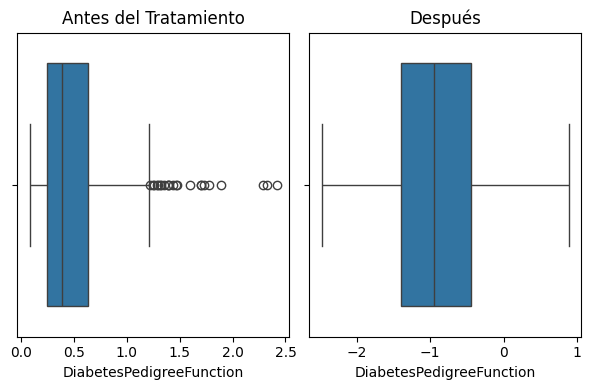

In [61]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, axis = plt.subplots(1, 2, figsize=(6, 4))

# Crear un histograma en el primer subplot
# Primera fila
sns.boxplot(data=X_train_imp, x="DiabetesPedigreeFunction", ax=axis[0])
axis[0].set_title("Antes del Tratamiento")
sns.boxplot(data=np.log(X_train_imp), x="DiabetesPedigreeFunction", ax=axis[1])
axis[1].set_title("Después")

# Mostrar la figura
plt.tight_layout()
plt.show()

In [62]:
# Aplicamos logaritmos en variables estudiadas con outliers
# Realizamos los cambios en train
X_train_imp["DiabetesPedigreeFunction"]=np.log(X_train_imp["DiabetesPedigreeFunction"])
## Realizamos los cambios en test
X_test_imp["DiabetesPedigreeFunction"]=np.log(X_test_imp["DiabetesPedigreeFunction"])

In [63]:
#Exportamos la base de datos procedada
train=pd.concat([X_train_imp, y_train], axis=1)
test=pd.concat([X_test_imp, y_test], axis=1)
df_proc=pd.concat([train, test], axis=0)
df_proc.to_csv("C:/Users/jjime/OneDrive/Git Hub/intro-ml/data/processed/diabetes.csv")

# **2. SELECCIÓN DE CARCATERÍSTICAS**

## 2.1. Aplicación de los métodos

### A) Feature importance con Random Forest

In [64]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train_imp, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Mostramos resultados
df_rf_imp = pd.DataFrame({'feature': X_train_imp.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
df_rf_imp

,feature,rf_importance
1,Glucose,26.021782
4,BMI,16.436384
6,Age,15.219536
5,DiabetesPedigreeFunction,12.769695
3,SkinThickness,11.476038
0,Pregnancies2,9.397057
2,BloodPressure,8.679507


### B) Permutation/Shuffle importance con Gradient Boosting Classifier

En nuestro caso, permutation importance proporciona el cambio en la métrica de scoring seleccionada cuando alteramos los valores de las características de estudio. Como en nuestro caso estamos trabajando con información médica, vamos a centrarnos en la métrica de f1 score pues comprende la precision y recall del modelo (de forma que máximizamos VP y min FN).

In [65]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train_imp, y_train, test_size=0.2, random_state=42)
# Entrenamos el modelo que va a porporcionarnos las predicciones por cada alteracion
model_xgb = XGBClassifier(random_state=42).fit(X_train1, y_train1)
# Intanciamos permitation forest
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='f1')
## Extraemos los valores a un df
df_perm_imp = pd.DataFrame({'feature': X_train1.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
1,Glucose,12.519619
4,BMI,12.438509
6,Age,9.766438
3,SkinThickness,6.652109
0,Pregnancies2,4.724939
5,DiabetesPedigreeFunction,3.706954
2,BloodPressure,-1.451186


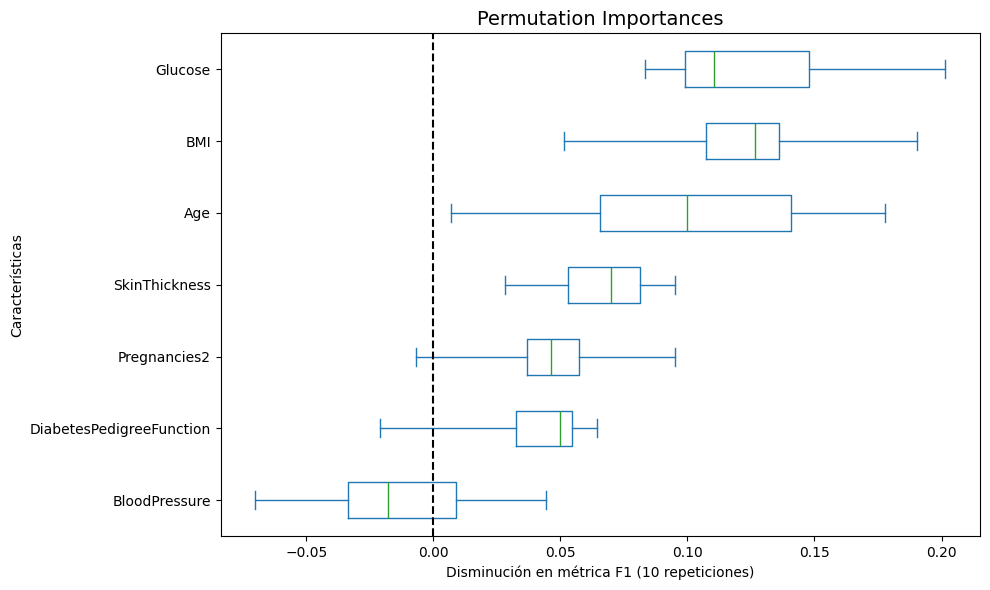

In [66]:
# Obtenemos orden de las variables (de menor a mayor importancia media)
# Esto asegura que el gráfico final estará ordenado
sorted_idx = perm.importances_mean.argsort()

# DataFrame para el Box Plot
# - Perm.importances: todos cambios en f1 por el numero de  repeticiones 
importances_df = pd.DataFrame(
    perm.importances[sorted_idx].T,
    columns=X_train_imp.columns[sorted_idx] 
)
importances_df

#Representamos gráficamente los cambios en el f1 score
fig, ax = plt.subplots(figsize=(10, 6))

# Usamos .plot.box() directamente sobre el DataFrame (columna por columna)
# vert=False -> gráfico horizontal
ax = importances_df.plot.box(vert=False, whis=10, ax=ax)
ax.set_title("Permutation Importances", fontsize=14)
ax.set_ylabel("Características")
ax.axvline(x=0, color="k", linestyle="--") # Línea vertical en 0 (sin ganancia/pérdida)
ax.set_xlabel("Disminución en métrica F1 (10 repeticiones)") 
fig.tight_layout()
plt.show()

### C) SHAP

In [67]:
# Ajustamos un modelo predictor para analizar la importancia de cada caract.
model_gbc = GradientBoostingClassifier(random_state=42).fit(X_train1, y_train1) 
# Instanciamos el shap explainer y extraemos los valores
explainer = shap.Explainer(model_gbc, X_val)  
shap_vals = explainer(X_val).values
# Pasamos los valores absolutos a un df
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_train_imp.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

,feature,shap_imp
1,Glucose,29.020621
6,Age,22.504623
4,BMI,14.222391
5,DiabetesPedigreeFunction,11.413228
3,SkinThickness,9.510824
2,BloodPressure,6.749534
0,Pregnancies2,6.578780


## 2.2. Selección de característica según los 3 métodos

In [68]:
#Añadimos resultados a un único df
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('perm_imp', ascending=False)

#Mostramos resultado
df_importances

,feature,rf_importance,perm_imp,shap_imp
4,Glucose,26.021782,12.519619,29.020621
1,BMI,16.436384,12.438509,14.222391
0,Age,15.219536,9.766438,22.504623
6,SkinThickness,11.476038,6.652109,9.510824
5,Pregnancies2,9.397057,4.724939,6.578780
3,DiabetesPedigreeFunction,12.769695,3.706954,11.413228
2,BloodPressure,8.679507,-1.451186,6.749534


In [69]:
# Eliminamos aquellas con un permutation importance negativo
df_sel=df_importances[(df_importances["rf_importance"]>2)&(df_importances["perm_imp"]>0)&(df_importances["shap_imp"]>1.8)]
df_sel

,feature,rf_importance,perm_imp,shap_imp
4,Glucose,26.021782,12.519619,29.020621
1,BMI,16.436384,12.438509,14.222391
0,Age,15.219536,9.766438,22.504623
6,SkinThickness,11.476038,6.652109,9.510824
5,Pregnancies2,9.397057,4.724939,6.578780
3,DiabetesPedigreeFunction,12.769695,3.706954,11.413228


In [70]:
# RESUMEN DE LA SELECCIÓN
## Eliminados
elm=df_importances["feature"][(df_importances["rf_importance"]<2)|(df_importances["shap_imp"]<2)|(df_importances["perm_imp"]<0)].to_list()
## Seleccionados
sel=df_sel["feature"].tolist()

# Texto
print(f"{len(elm)} columnas eliminadas:")
print(elm)
print("-"*120)
print(f"{len(sel)} columnas seleccionadas:")
print(sel)

1 columnas eliminadas:
['BloodPressure']
------------------------------------------------------------------------------------------------------------------------
6 columnas seleccionadas:
['Glucose', 'BMI', 'Age', 'SkinThickness', 'Pregnancies2', 'DiabetesPedigreeFunction']


## 2.3. Comprobación vif y correlaciones

In [107]:
# VIF
## Variable Xi: añdimos cte. para no asumir que regresión pasa por (0,0) y tener problemas con R2 de vif
x_vif=add_constant(X_train_imp[sel])

## Cálculo: x_vif.values (array con los datos), i valor de la columna que asuma Yi
vif = pd.Series([variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])], index=x_vif.columns).drop(index="const")
vif[vif>5]

Series([], dtype: float64)

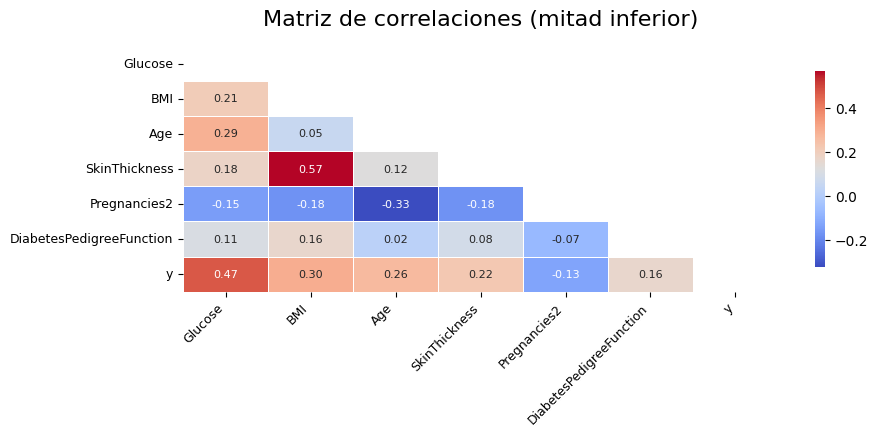

In [72]:
#Análisis de correlaciones entre regresores
x_vif.drop(columns="const", axis=1, inplace=True)
x_vif['y'] = y_train
corr = x_vif.corr()

#Mapa de correlaciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    corr, mask=np.triu(np.ones_like(corr, dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

## 2.4. Ingeniería de características

In [84]:
#Testamos producto de variables correladas
var_test=X_train_imp[['BMI', 'SkinThickness']]
var_test["Product"]=var_test['BMI']*var_test['SkinThickness']
# Instanciar y entrenamos el modelo (solo define la función, aún no entrena)
test = sm.Logit(y_train, sm.add_constant(var_test)).fit()

Optimization terminated successfully.
         Current function value: 0.597548
         Iterations 6


C:\Users\jjime\AppData\Local\Temp\ipykernel_12696\3917988330.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  var_test["Product"]=var_test['BMI']*var_test['SkinThickness']


In [88]:
# Guardamos los pvalores en una serie
result=test.pvalues
# Print de las variables resultantes
print(f"Variables significativas: {list(result[result<0.05].index)}" if len(result[result<0.05].index)>1 else "Ninguna variable es significativa")
print(f"Variables no significativas: {list(result[result>0.05].index)}" if len(result[result>0.05].index)>1 else "Todas las variables son significativas")

Variables significativas: ['const', 'BMI', 'SkinThickness', 'Product']
Todas las variables son significativas


## 2.4. Cross_validation

Vamos a analizar las siguientes estrategias:

1. Dejamos todas las variables correlacionadas
2. Eliminamos ``BMI``
3. Eliminamos ``SkinThickness``
4. Añadimos ``BMI``*``SkinThickness``

In [89]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics1=[]
# Versión 1: todas las características
met1_x=x_vif.drop(columns=["y"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met1_x, y_train, cv=5, scoring=scoring)
    metrics1.append(float(round(cv_results1.mean()*100, 3)))

In [90]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics2=[]
# Versión 1: todas las características
met2_x=met1_x.drop(columns=["BMI"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met2_x, y_train, cv=5, scoring=scoring)
    metrics2.append(float(round(cv_results2.mean()*100, 3)))

In [91]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics3=[]
# Versión 1: todas las características
met3_x=met1_x.drop(columns=["SkinThickness"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results3 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met3_x, y_train, cv=5, scoring=scoring)
    metrics3.append(float(round(cv_results3.mean()*100, 3)))

In [92]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics4=[]
# Versión 1: todas las características
met4_x=met1_x
met4_x["product"]=met4_x['BMI']*met4_x['SkinThickness']

#Cross validation por cada scoring
for scoring in scorings:
    cv_results4 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met4_x, y_train, cv=5, scoring=scoring)
    metrics4.append(float(round(cv_results4.mean()*100, 3)))

In [95]:
# Tabla resumen
pd.DataFrame([metrics1, metrics2, metrics3, metrics4], index=["Df inicial", "- BMI", "- SkinThickness", "+ Product"], columns=scorings).sort_values(by="f1", ascending=False)

,f1,recall,precision
Df inicial,65.227,61.617,69.998
+ Product,64.425,60.677,70.307
- SkinThickness,63.543,60.233,67.759
- BMI,59.889,54.683,66.363


# 3. Modelado

## 3.1. Entrenamiento

### A) Funcion de pureza GINI

In [143]:
#Intanciamos y configramos el modelo
gini_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    max_features=X_train_imp[sel].shape[1]//2, 
    min_samples_leaf=int(0.025*X_train_imp.shape[0]), 
    random_state=42).fit(X_train_imp[sel], y_train)

In [146]:
#Vemos los resultados
print(export_text(gini_tree, feature_names=list(X_train_imp[sel].columns), class_names = ["No diabético", "Diabético"], show_weights=True))

|--- Glucose <= 127.50
|   |--- BMI <= 27.00
|   |   |--- Glucose <= 105.50
|   |   |   |--- weights: [61.00, 0.00] class: No diabético
|   |   |--- Glucose >  105.50
|   |   |   |--- SkinThickness <= 24.50
|   |   |   |   |--- weights: [16.00, 2.00] class: No diabético
|   |   |   |--- SkinThickness >  24.50
|   |   |   |   |--- weights: [21.00, 0.00] class: No diabético
|   |--- BMI >  27.00
|   |   |--- Age <= 30.50
|   |   |   |--- SkinThickness <= 28.26
|   |   |   |   |--- Pregnancies2 <= 2.93
|   |   |   |   |   |--- BMI <= 31.97
|   |   |   |   |   |   |--- weights: [24.00, 1.00] class: No diabético
|   |   |   |   |   |--- BMI >  31.97
|   |   |   |   |   |   |--- weights: [15.00, 3.00] class: No diabético
|   |   |   |   |--- Pregnancies2 >  2.93
|   |   |   |   |   |--- weights: [27.00, 0.00] class: No diabético
|   |   |   |--- SkinThickness >  28.26
|   |   |   |   |--- DiabetesPedigreeFunction <= -0.37
|   |   |   |   |   |--- BMI <= 33.65
|   |   |   |   |   |   |--- wei

### B) Función de pureza Log-loss

In [145]:
#Intanciamos y configramos el modelo
log_loss_tree = DecisionTreeClassifier(
    criterion="log_loss",
    max_depth=6,
    max_features=X_train_imp[sel].shape[1]//2, 
    min_samples_leaf=int(0.025*X_train_imp.shape[0]), 
    random_state=42).fit(X_train_imp[sel], y_train)

In [147]:
#Vemos los resultados
print(export_text(log_loss_tree, feature_names=list(X_train_imp[sel].columns), class_names = ["No diabético", "Diabético"], show_weights=True))

|--- Glucose <= 127.50
|   |--- BMI <= 26.45
|   |   |--- DiabetesPedigreeFunction <= -0.41
|   |   |   |--- weights: [78.00, 0.00] class: No diabético
|   |   |--- DiabetesPedigreeFunction >  -0.41
|   |   |   |--- weights: [14.00, 1.00] class: No diabético
|   |--- BMI >  26.45
|   |   |--- Age <= 28.50
|   |   |   |--- SkinThickness <= 27.42
|   |   |   |   |--- BMI <= 32.70
|   |   |   |   |   |--- weights: [43.00, 0.00] class: No diabético
|   |   |   |   |--- BMI >  32.70
|   |   |   |   |   |--- weights: [15.00, 2.00] class: No diabético
|   |   |   |--- SkinThickness >  27.42
|   |   |   |   |--- DiabetesPedigreeFunction <= -0.70
|   |   |   |   |   |--- DiabetesPedigreeFunction <= -1.26
|   |   |   |   |   |   |--- weights: [23.00, 7.00] class: No diabético
|   |   |   |   |   |--- DiabetesPedigreeFunction >  -1.26
|   |   |   |   |   |   |--- weights: [18.00, 0.00] class: No diabético
|   |   |   |   |--- DiabetesPedigreeFunction >  -0.70
|   |   |   |   |   |--- Age <= 25.50

## 3.2. Evaluación

In [177]:
# Pureza log-loss
train_pred_log = log_loss_tree.predict(X_train_imp[sel])
test_pred_log = log_loss_tree.predict(X_test[sel])

# Pureza gini
train_pred_gini = gini_tree.predict(X_train_imp[sel])
test_pred_gini = gini_tree.predict (X_test[sel])

## Métricas
print("-"*60)
print("FUNCION DE PUREZA GINI")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred_gini, test_pred_gini))
print("-"*60)
print("FUNCION DE PUREZA LOG-LOSS")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred_log, test_pred_log))

------------------------------------------------------------
FUNCION DE PUREZA GINI
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision      F1
Train        0.80757  0.68056      0.87755    0.75385 0.71533
Test         0.77124  0.74510      0.78431    0.63333 0.68468
Diferencia   0.03632 -0.06454      0.09324    0.12051 0.03064
------------------------------------------------------------
FUNCION DE PUREZA LOG-LOSS
------------------------------------------------------------
            Accuracy   Recall  Specificity  Precision      F1
Train        0.81414  0.75000      0.84949    0.73303 0.74142
Test         0.77778  0.82353      0.75490    0.62687 0.71186
Diferencia   0.03637 -0.07353      0.09459    0.10617 0.02955


[]

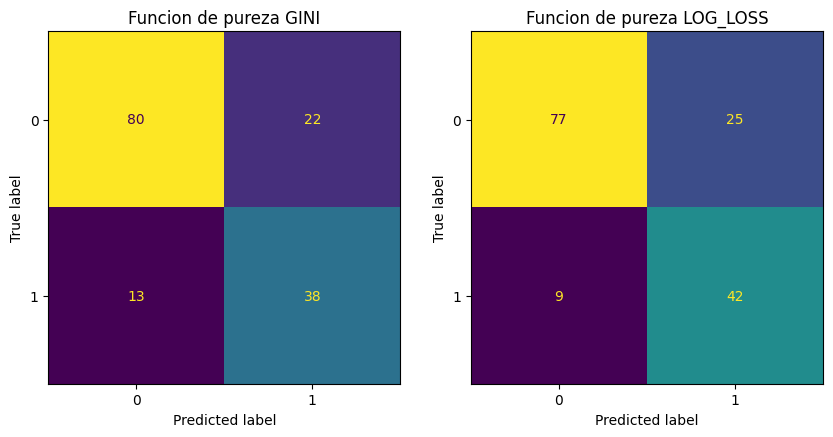

In [178]:
#Matriz de confusión
## GINI
cm_gini = confusion_matrix(y_test, test_pred_gini)
## LOG-LOSS
cm_log = confusion_matrix(y_test, test_pred_log)

# Representación
fig, axis=plt.subplots(1,2, figsize=(10,5))
ConfusionMatrixDisplay(confusion_matrix=cm_gini).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Funcion de pureza GINI")
ConfusionMatrixDisplay(confusion_matrix=cm_log).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Funcion de pureza LOG_LOSS")
plt.plot()

## 3.3. Optimización de hiperparámetros

In [ ]:
# Tenemos que obtener un conjunto de validación para validar la decisión de qué algoritmo elegir
X_train_sc1, X_val_sc, y_train1, y_val = train_test_split(X_train_imp[sel], y_train, test_size=0.2, random_state=42)

#Referenciamos el modelo
log_loss_tree = DecisionTreeClassifier(
    criterion="log_loss",
    max_depth=6,
    max_features=X_train_imp[sel].shape[1]//2, 
    min_samples_leaf=int(0.025*X_train_imp.shape[0]), 
    random_state=42)

In [185]:
int(0.015*X_train_imp.shape[0])

9

In [ ]:
#Espacio de búsqueda más acotado
param_dist = {
    "max_depth": [4, 6, 8, 10], #profundida máxima del árbol
    "min_samples_split": [int(0.015*X_train_imp.shape[0]), 
                          int(0.025*X_train_imp.shape[0]), 
                          int(0.035*X_train_imp.shape[0]), 
                          int(0.045*X_train_imp.shape[0])], #observaciones minimimas para hacer un nodo interno
    "min_samples_leaf": 




}

# Cambiar scoring a métrica de clasificación
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_dist,
    scoring='roc_auc',           # métrica adecuada para clasificación binaria
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Ejecutamos la búsqueda 
grid_search.fit(X_train_sc1, y_train1)
print("Mejores hiperparámetros:")
print(grid_search.best_params_)
best_model = grid_search.best_estimator_ #Guardamos los resultados